# Lab 05: The Dark Companion, Two Years Later

**ASTR 457, Fall 2026, posted Sat Oct 3, due Fri Oct 9 by Noon (extended) (fork → PR, as always)**

*Why this lab: every orbit in the literature, from Gaia's black-hole binaries to the planets David Charbonneau talked about on Tuesday, is a posterior distribution over six or seven parameters that nobody can write down in closed form. Sampling it, knowing when the sampler has actually converged, and turning the samples into a number with an honest error bar is the core professional skill of modern astrophysics, and the place where confident, fluent, wrong analyses are most common.*

On Day 1 you watched a star's radial velocity drift over ten nights and inferred an unseen companion from
the slope alone. This is that programme, two and a half years on. Every one of you has your own star:
`data/<your netid>.csv`, with columns `t_days` (time of each spectrum, from the first epoch), `rv_kms`
(the measured radial velocity) and `sigma_rv_kms` (the pipeline's per-epoch uncertainty). The star was
observed in three observing seasons over about 900 days, 28 to 44 epochs in all. It is a **single-lined
spectroscopic binary**: you see one star's lines, the companion contributes no light, and the visible star
follows a Keplerian orbit,

$$v_r(t) = \gamma + K\left[\cos\big(\nu(t) + \omega\big) + e\cos\omega\right],$$

with period $P$, semi-amplitude $K$, eccentricity $e$, argument of periastron $\omega$, a time of periastron
$T_p$, systemic velocity $\gamma$, and $\nu(t)$ the true anomaly (the angle around the orbit, which you get
from Kepler's equation; a function is provided). What you are really after is the **mass function**

$$f(M) = \frac{P K^3 (1 - e^2)^{3/2}}{2\pi G} = \frac{M_2^3 \sin^3 i}{(M_1 + M_2)^2},$$

a lower limit on the companion's mass, in solar masses. If it comes out above about $3\,M_\odot$ for a
Sun-like primary, you have a black hole candidate, the way Gaia BH1 was found (El-Badry et al. 2023, the Sep 8
colloquium). In the units of your file, $f(M) = 1.0361\times10^{-7}\,(1-e^2)^{3/2} K^3 P$ with $K$ in km/s
and $P$ in days.

I know your true $P$, $K$, $e$ and $f(M)$. You don't, your classmates' stars are different, and so is the
sampling. **One more thing I know and you don't: the quoted `sigma_rv_kms` is not the whole error.** Real
radial velocities carry an extra scatter, called jitter, from the star's own surface and from template
mismatch, and it is not in the pipeline number.

**How this is graded.** As always, on whether your answers are *right* and your uncertainties are *honest*:
your reported $P$, $K$, $e$ and $f(M)$ are compared to your truth in units of your own reported uncertainty.
Anti-sandbagging cap: your $\sigma_K$ may not exceed $3\times$ a reference posterior width I compute for your
dataset. Padded error bars lose points like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document it in Part 4. You
may be selected to defend this lab orally; the defense is easy if you did the work.

Weights: Part 1 15%, Part 2 40%, Part 3 35%, Part 4 10%.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from scipy.optimize import minimize
from astropy.timeseries import LombScargle

NETID = 'yournetid'   # <-- set this
d = np.genfromtxt(f'data_05.csv', delimiter=',', names=True)
t, rv, sig = d['t_days'], d['rv_kms'], d['sigma_rv_kms']
print(f"{t.size} epochs over {t.max() - t.min():.0f} days; median quoted error {np.median(sig):.2f} km/s")

def kepler_rv(t, P, K, e, omega, Tp, gamma):
    """Radial velocity of the visible star in a Keplerian orbit.
    P period [d], K semi-amplitude [km/s], e eccentricity, omega argument of periastron [rad],
    Tp a time of periastron [d], gamma systemic velocity [km/s]. Solves Kepler's equation by Newton iteration."""
    M = 2. * np.pi * ((t - Tp) / P % 1.0)            # mean anomaly
    E = M.copy()                                     # eccentric anomaly
    for _ in range(30):
        E = E - (E - e * np.sin(E) - M) / (1. - e * np.cos(E))
    nu = 2. * np.arctan2(np.sqrt(1. + e) * np.sin(E / 2.), np.sqrt(1. - e) * np.cos(E / 2.))   # true anomaly
    return gamma + K * (np.cos(nu + omega) + e * np.cos(omega))

def mass_function(P, K, e):
    """f(M) in solar masses, for P in days and K in km/s."""
    return 1.0361e-7 * (1. - e**2)**1.5 * K**3 * P

43 epochs over 868 days; median quoted error 1.70 km/s


In [2]:
#additional imports
from scipy.signal import find_peaks
from IPython.display import display, Math

## Part 1: Look first, then find the period (15%)

Plot the radial velocities against time with their error bars. Then find candidate orbital periods with a
Lomb-Scargle periodogram of the velocities (`astropy.timeseries.LombScargle`, Day 7's periodogram, formally
taught on Oct 20/22; for now it is a tool that ranks periods). Plot the periodogram. Then, for the best two or
three candidate periods, phase-fold the data and look.

Answer, in a few sentences: how many candidate periods are plausible from the periodogram alone, and why does
a Lomb-Scargle periodogram (which fits a *sinusoid*) not settle the question for an eccentric orbit? What
feature of the sampling (look at the gaps) produces the other peaks?


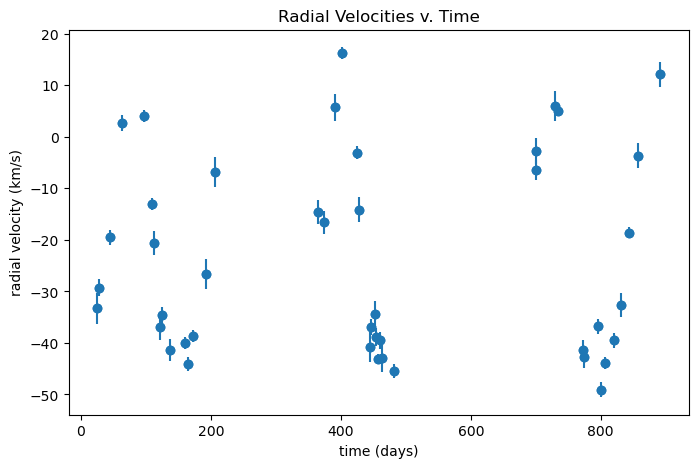

In [3]:
# Part 1: your work here
plt.figure(figsize=(8, 5))
plt.scatter(t, rv)
plt.errorbar(t, rv, yerr=sig, fmt='o', color='C0')
plt.title('Radial Velocities v. Time'), plt.xlabel('time (days)'), plt.ylabel('radial velocity (km/s)')
plt.show()

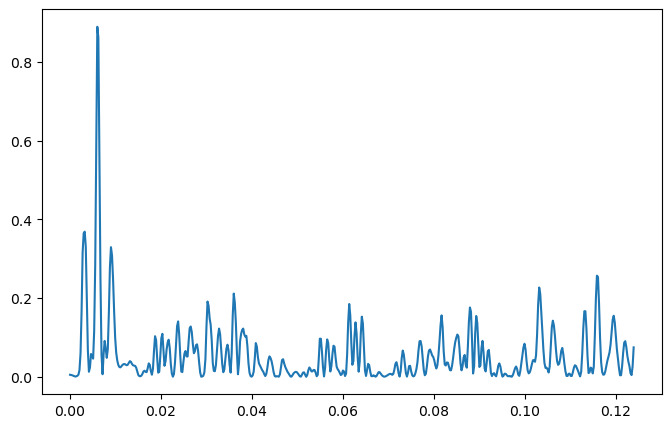

In [4]:
plt.figure(figsize=(8, 5))
frequency, power = LombScargle(t, rv).autopower()
plt.plot(frequency, power)
plt.show()

In [5]:
peaks, _ = find_peaks(power)
best = peaks[np.argsort(power[peaks])[-3:]]

P1, P2, P3 = 1 / frequency[best]

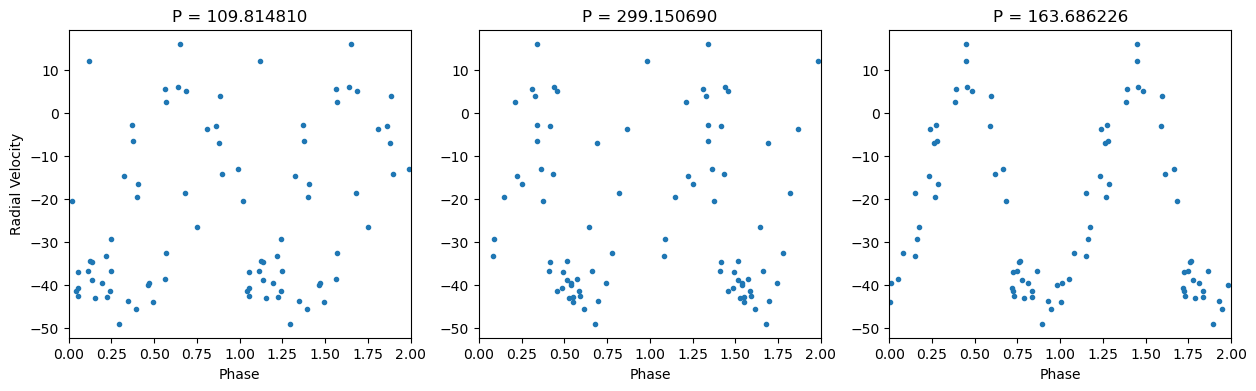

In [6]:
periods = [P1, P2, P3]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, P in zip(axes, periods):
    phase = (t % P) / P

    idx = np.argsort(phase)

    ax.plot(phase[idx], rv[idx], "o", ms=3)
    ax.plot(phase[idx] + 1, rv[idx], "o", ms=3, color='C0')

    ax.set_title(f"P = {P:.6f}")
    ax.set_xlabel("Phase")
    ax.set_xlim(0, 2)

axes[0].set_ylabel("Radial Velocity")
plt.show()

**ANSWER (a few sentences):**

Looking at the periodogram and the three phase folded periods, there is one notable candiate for the period. However this does not necessarily settle the question of the period for our orbit. This is because there are gaps of time when our star is not visible. Along with the velocity not being wholly consistent in its orbit.

## Part 2: Sample the posterior (40%)

Fit the six orbital parameters **plus a jitter term** $s$ with `emcee`. The likelihood for epoch $i$ is
Gaussian with variance $\sigma_i^2 + s^2$; write it out (including the $\log$ of the variance, which is not a
constant once $s$ is a parameter). You will need to:

1. **Write the log-likelihood, log-prior and log-posterior.** State every prior and justify it in one line
   each. Two traps: $\omega$ and $T_p$ are periodic ($T_p$ is only defined modulo $P$), and `emcee` does not
   wrap angles, so a hard prior wall at $0$ or $2\pi$ can cut a posterior mode in half. Either bound each of
   them within half a period of your starting value, or reparameterize with $\sqrt{e}\cos\omega$ and
   $\sqrt{e}\sin\omega$ (which also gives a uniform prior on $e$ without a wall at zero). Jitter is
   positive: sample $\ln s$.
2. **Start the walkers sensibly.** A maximum-likelihood fit from each plausible Part 1 period, with several
   starting $\omega$ and $T_p$ each, then compare the log-likelihoods; start the walkers in a small ball
   around the best one. That comparison is the check: report the log-likelihood of the runner-up.
3. **Run, then decide when it is done.** Compute the integrated autocorrelation time $\tau$ for every
   parameter (`sampler.get_autocorr_time`). Here $\tau$ is about 50 to 100 steps, so 64 walkers for
   10,000 steps is plenty (a few minutes) and `emcee`'s own rule is a chain longer than $50\tau$. A
   common choice is to discard a few $\tau$ as burn-in and thin by about $\tau/2$; say what you chose
   and why. Plot the chains. If $\tau$ cannot be estimated, your chain is too short; say so and fix it.
4. **Corner plot.** Which parameters are correlated, and why physically?
5. **Report** $P$, $K$, $e$, $\gamma$, the jitter $s$, and $f(M)$, each as a median and 68% interval.
   **$f(M)$ is computed for every posterior sample**, not from the medians of $P$, $K$ and $e$; explain in
   one sentence why that matters.
6. **Posterior predictive check.** Draw a few hundred orbits from the posterior and plot them over the data,
   phase-folded at the median period. Plot the normalized residuals with the *total* error bar
   $\sqrt{\sigma_i^2 + s^2}$. Is what is left noise?


In [7]:
# Part 2: your work here
# P, K, e, omega, Tp, gamma

def neglogL(theta, t, rv, sigma):
    P, K, e, omega, Tp, gamma, ln_s = theta

    s = np.exp(ln_s)

    rv_pred = kepler_rv(t, P, K, e, omega, Tp, gamma)

    var = sigma**2 + s**2
    resid = rv - rv_pred

    return 0.5 * np.sum(resid**2 / var + np.log(2*np.pi*var))

def logL(theta, t, rv, sig):
    P, K, e, omega, Tp, gamma, ln_s = theta

    s = np.exp(ln_s)

    rv_pred = kepler_rv(t, P, K, e, omega, Tp, gamma)

    var = sig**2 + s**2
    resid = rv - rv_pred

    return -0.5 * np.sum(resid**2 / var + np.log(2*np.pi*var))

"""Radial velocity of the visible star in a Keplerian orbit.
P period [d], K semi-amplitude [km/s], e eccentricity, omega argument of periastron [rad],
Tp a time of periastron [d], gamma systemic velocity [km/s]. Solves Kepler's equation by Newton iteration."""

theta = [P3, 0.5 * (rv.max() - rv.min()), 0.3, np.pi/2, P3/2, np.median(rv), np.median(sig)]
theta2 = [P3, 0.5 * (rv.max() - rv.min()), 0.3, np.pi, P3/3, np.median(rv), np.median(sig)]
theta3 = [P3, 0.5 * (rv.max() - rv.min()), 0.3, (2/3)*np.pi, P3/4, np.median(rv), np.median(sig)]
m = minimize(neglogL, theta, args = (t, rv, sig), method='Nelder-Mead')
m2 = minimize(neglogL, theta2, args = (t, rv, sig), method='Nelder-Mead')
m3 = minimize(neglogL, theta3, args = (t, rv, sig), method='Nelder-Mead')
P, K, e, omega0, Tp0, gamma, s = m.x
P2, K2, e2, omega2, Tp2, gamma2, s2 = m2.x
P3, K3, e3, omega3, Tp3, gamma3, s3 = m3.x
s, s2, s3 = np.exp(s), np.exp(s2), np.exp(s3)

print(f'Period = {P:.5f}, {P2:.5f}, {P3:.5f}')
print(f'Semi-amplitude = {K:.5f}, {K2:.5f}, {K3:.5f}')
print(f'Eccentricity = {e:.5f}, {e2:.5f}, {e3:.5f}')
print(f'Omega argument of periastron = {omega0:.5f}, {omega2:.5f}, {omega3:.5f}')
print(f'Time of periastron = {Tp0:.5f}, {Tp2:.5f}, {Tp3:.5f}')
print(f'Gamma systemic velocity = {gamma:.5f}, {gamma2:.5f}, {gamma3:.5f}')
print(f'Jitter = {s:.5f}, {s2:.5f}, {s3:.5f}')

Period = 160.41397, 317.37571, 160.56975
Semi-amplitude = 28.93585, 23.09544, 28.65241
Eccentricity = 0.20996, 0.67737, -0.17932
Omega argument of periastron = 0.65388, 1.37239, 3.87622
Time of periastron = 93.51506, 109.82969, 175.45536
Gamma systemic velocity = -20.54668, -20.65796, -20.66726
Jitter = 2.70963, 9.87040, 2.29957


In [8]:
def logprior(theta):
    P, K, e, omega, Tp, gamma, s = theta

    if (100.0 < P < 300.0) & (1.0 < K < 50.0) & (0.1 <= e <= 0.6) & ((omega0 - P/2.0) < omega < (omega0 + P/2.0)) & ((Tp0 - P/2.0) < Tp < (Tp0 + P/2.0)) & (-50.0 < gamma < 50.0) & (-10.0 < s < 10.0):
        return 0.0
        
    return -np.inf

For each prior I looked at my results from the negative log likelihood, information from part 1, and my general knowledge on these parameters to choose reasonable bounds. I did my best to give decent room without making them too broad. For the omega argument and time of peristron I choose to bound them within half of my starting period.

In [9]:
def logprob(theta, t, rv, sig):
    lp = logprior(theta)
    
    if not np.isfinite(lp):
        return -np.inf

    return lp + logL(theta, t, rv, sig)

In [10]:
pos = m.x + 1e-4 * np.random.randn(32, 7)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, logprob, args=(t, rv, sig)
)
sampler.run_mcmc(pos, 5000);

Text(0.5, 0, 'step number')

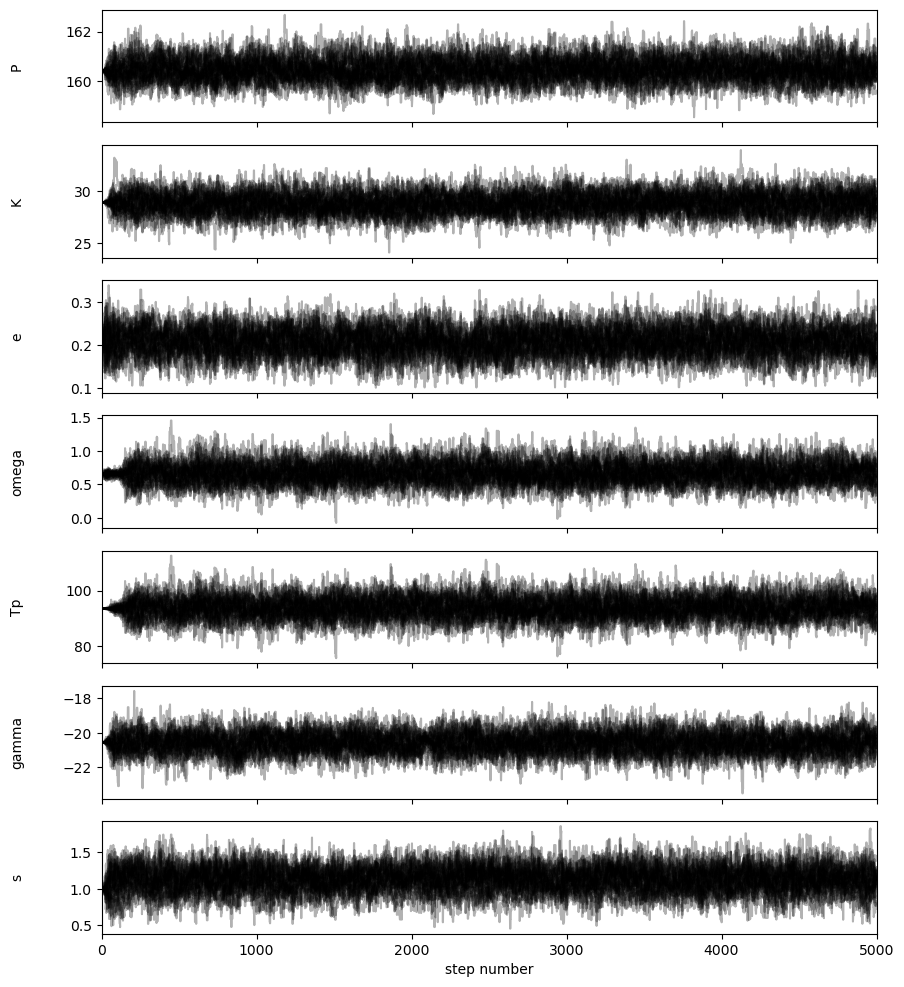

In [11]:
fig, axes = plt.subplots(7, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()
labels = ['P', 'K', 'e', 'omega', 'Tp', 'gamma', 's']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

In [12]:
tau = sampler.get_autocorr_time()
print(tau)

[72.44834601 69.2460452  73.3689243  72.40487633 73.98316652 76.38797266
 75.61850279]


In [13]:
flat_samples = sampler.get_chain(discard=100, thin=int((tau.max())/2), flat=True)
print(flat_samples.shape)

(4096, 7)


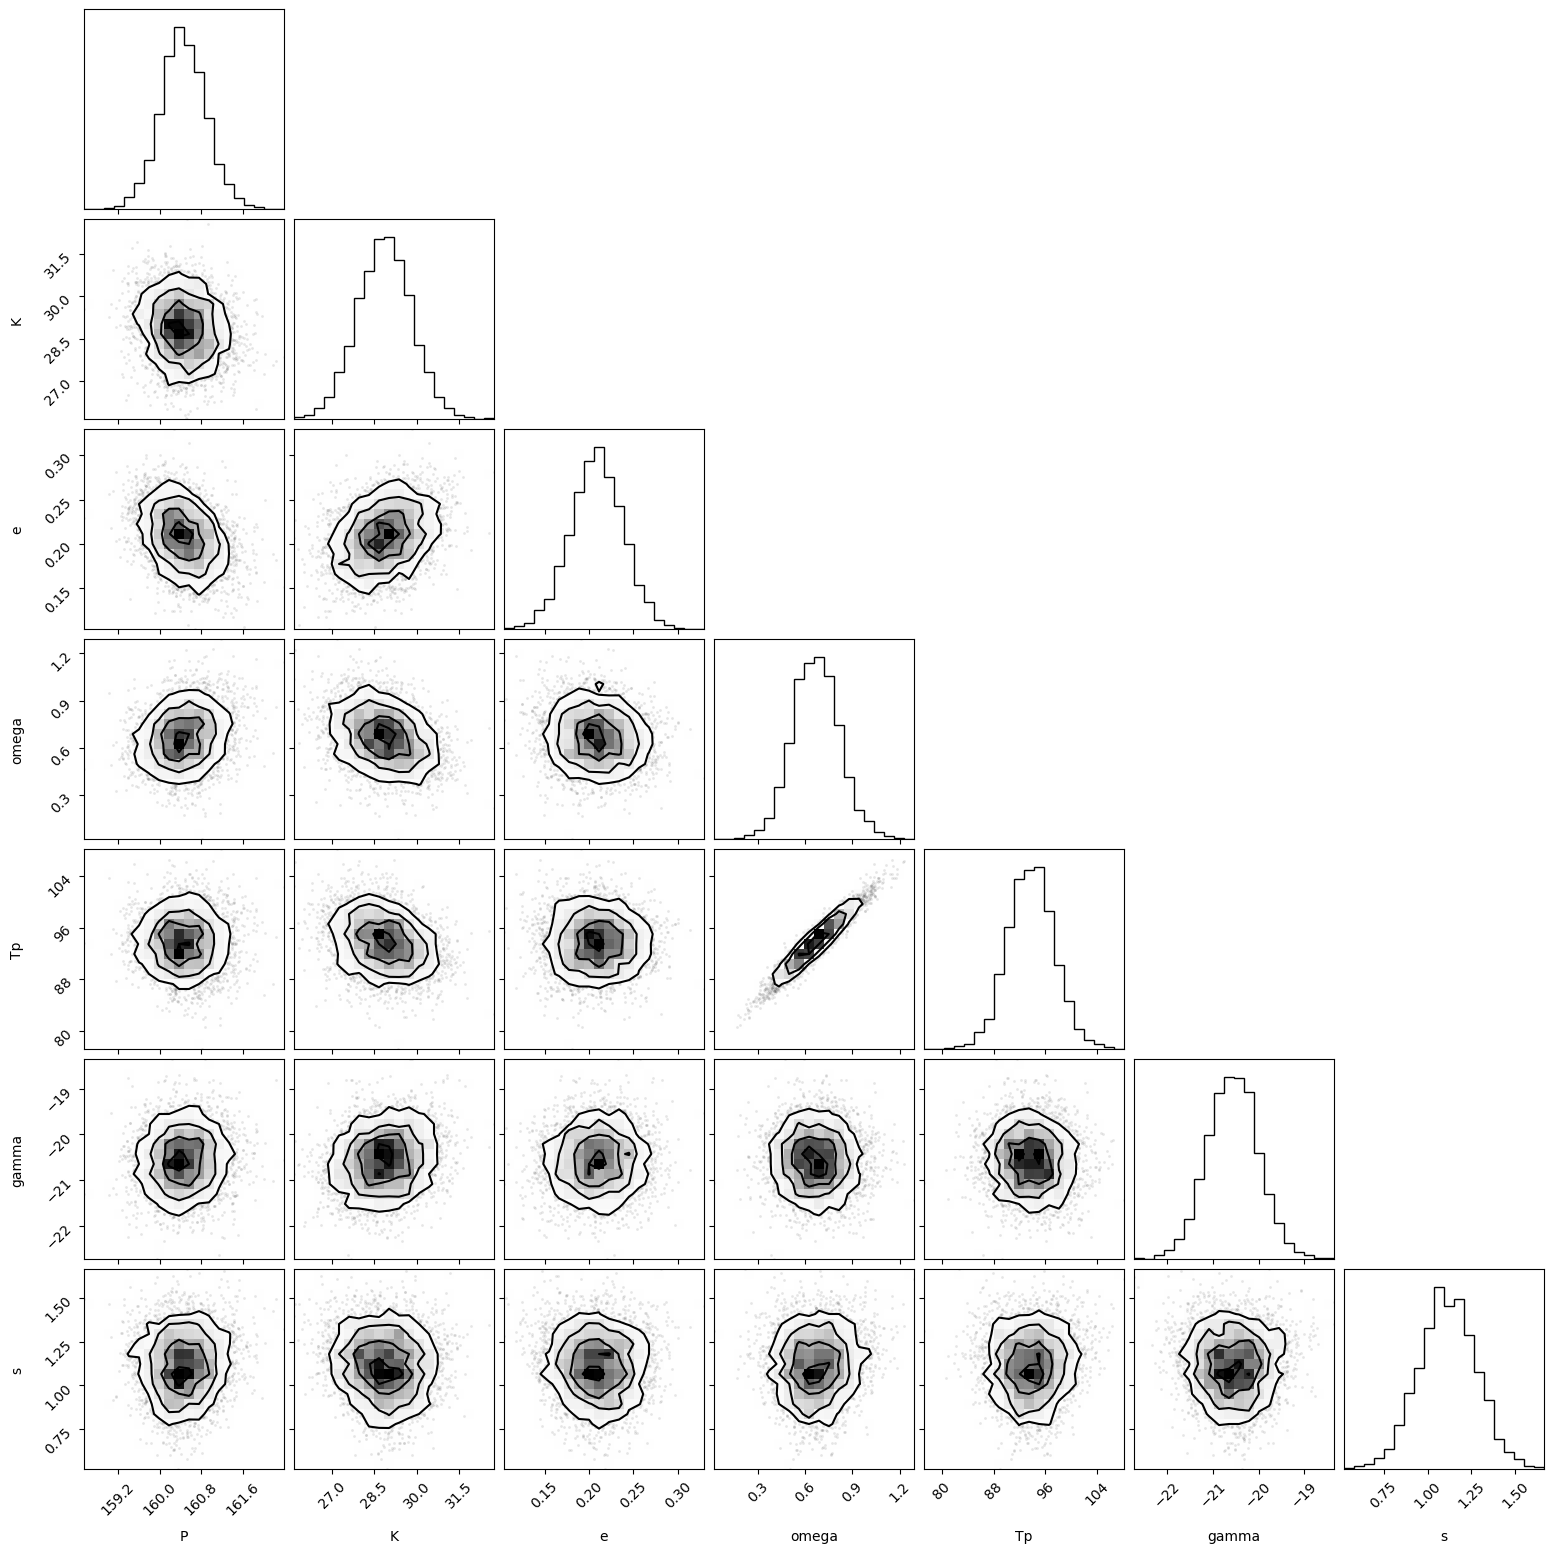

In [14]:
fig = corner.corner(
    flat_samples, labels=labels
);

Tp and omega are correlated with one another since physically omega depends on Tp.

In [15]:
labels = ["P", "K", "e", r"\omega", r"T_p", r"\gamma", "s"]

samples = flat_samples.copy()
samples[:, 6] = np.exp(samples[:, 6])
 
for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = r"\mathrm{{{3}}} = {0:.5f}_{{-{1:.5f}}}^{{+{2:.5f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [16]:
sd = np.std(samples, axis=0)
print(sd)

[0.44496012 0.95101041 0.02951457 0.14957284 3.60830974 0.56064991
 0.50853673]


In [17]:
P = flat_samples[:, 0]
K = flat_samples[:, 1]
e = flat_samples[:, 2]

fM = 1.0361e-7 * (1 - e**2)**1.5 * K**3 * P

p16, p50, p84 = np.percentile(fM, [16, 50, 84])

err = ((p50-p16) + (p84-p50))/2
print(f'f(M) = {p50:.5f} +/- {err:.5f}')

f(M) = 0.37278 +/- 0.03518


f(M) is computed for every posterior sample, not from the P, K, and e medians due to the potential variance in each of those values. It also allows us to calculate the resulting error.

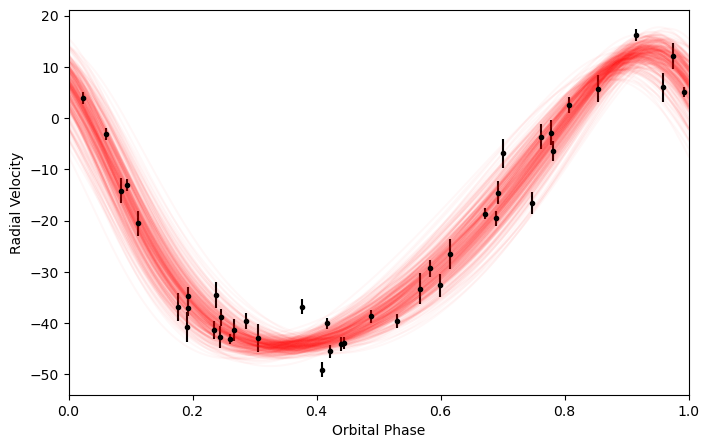

In [18]:
theta_med = np.median(flat_samples, axis=0)
P, K, e, omega, Tp, gamma, ln_s = theta_med

phase = ((t - Tp) / P) % 1.0

idx = np.argsort(phase)
phase_s = phase[idx]
rv_s = rv[idx]
sig_s = sig[idx]

plt.figure(figsize=(8,5))

plt.errorbar(phase_s, rv_s, yerr=sig_s, fmt='o', color='k', ms=3)

draws = flat_samples[np.random.choice(len(flat_samples),300,replace=False)]

phase_grid = np.linspace(0, 1, 500)

for Pj, Kj, ej, omegaj, Tpj, gammaj, ln_sj in draws:
    t_grid = Tpj + phase_grid * Pj

    rv_grid = kepler_rv(t_grid, Pj, Kj, ej, omegaj, Tpj, gammaj)

    plt.plot(phase_grid, rv_grid, color='red', alpha=0.03)

plt.xlabel('Orbital Phase')
plt.ylabel('Radial Velocity')
plt.xlim(0, 1)
plt.show()

In [19]:
P_true = 161.0
K_true = 29.0
e_true = 0.25
omega_true = 0.67
Tp_true = 91.0
gamma_true = -20.3        
s_true = 2.9

rv_true = kepler_rv(t, P_true, K_true, e_true, omega_true, Tp_true, gamma_true)

rng = np.random.default_rng(100726)
rv_sim = rv_true + rng.normal(0, np.sqrt(sig**2 + s_true**2), size=len(t))

In [20]:
def neglogL_sim(theta, t, rv_sim, sigma):
    P, K, e, omega, Tp, gamma, ln_s = theta

    s = np.exp(ln_s)

    rv_pred = kepler_rv(t, P, K, e, omega, Tp, gamma)

    var = sigma**2 + s**2
    resid = rv_sim - rv_pred

    return 0.5 * np.sum(resid**2 / var + np.log(2*np.pi*var))

def logL_sim(theta, t, rv_sim, sig):
    P, K, e, omega, Tp, gamma, ln_s = theta

    s = np.exp(ln_s)

    rv_pred = kepler_rv(t, P, K, e, omega, Tp, gamma)

    var = sig**2 + s**2
    resid = rv_sim - rv_pred

    return -0.5 * np.sum(resid**2 / var + np.log(2*np.pi*var))

theta_sim = [170, 0.5 * (rv_sim.max() - rv_sim.min()), 0.3, np.pi/2, 85, np.median(rv_sim), np.exp((np.median(sig)))]
m_sim = minimize(neglogL_sim, theta_sim, args = (t, rv_sim, sig), method='Nelder-Mead')
P0, K0, e0, omega0, Tp0, gamma0, s0 = m_sim.x

def logprior_sim(theta_sim):
    P, K, e, omega, Tp, gamma, s = theta_sim

    if (100.0 < P < 300.0) & (1.0 < K < 50.0) & (0.1 <= e <= 0.6) & ((omega0 - P/2.0) < omega < (omega0 + P/2.0)) & ((Tp0 - P/2.0) < Tp < (Tp0 + P/2.0)) & (-50.0 < gamma < 50.0) & (-10.0 < s < 10.0):
        return 0.0
        
    return -np.inf

def logprob_sim(theta_sim, t, rv_sim, sig):
    lp = logprior_sim(theta_sim)
    
    if not np.isfinite(lp):
        return -np.inf

    return lp + logL_sim(theta_sim, t, rv_sim, sig)

In [21]:
pos = m_sim.x + 1e-4 * np.random.randn(32, 7)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, logprob_sim, args=(t, rv_sim, sig)
)
sampler.run_mcmc(pos, 5000);

Text(0.5, 0, 'step number')

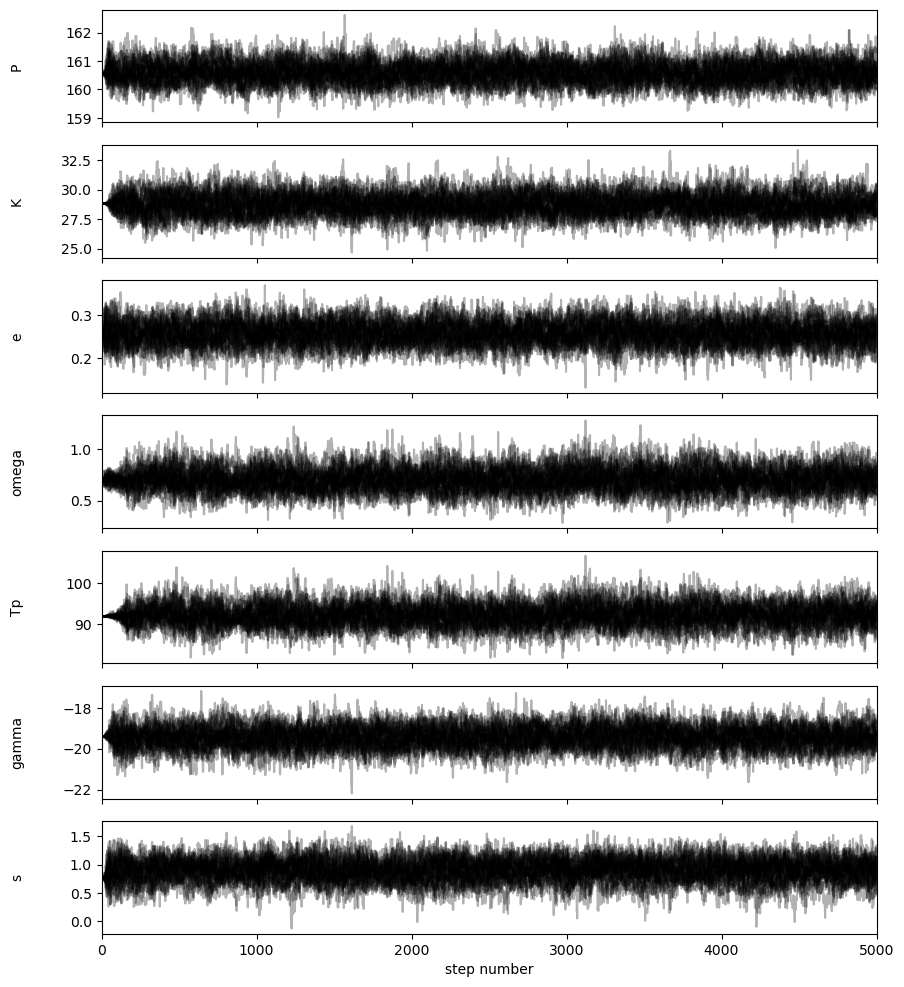

In [22]:
fig, axes = plt.subplots(7, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()
labels = ['P', 'K', 'e', 'omega', 'Tp', 'gamma', 's']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

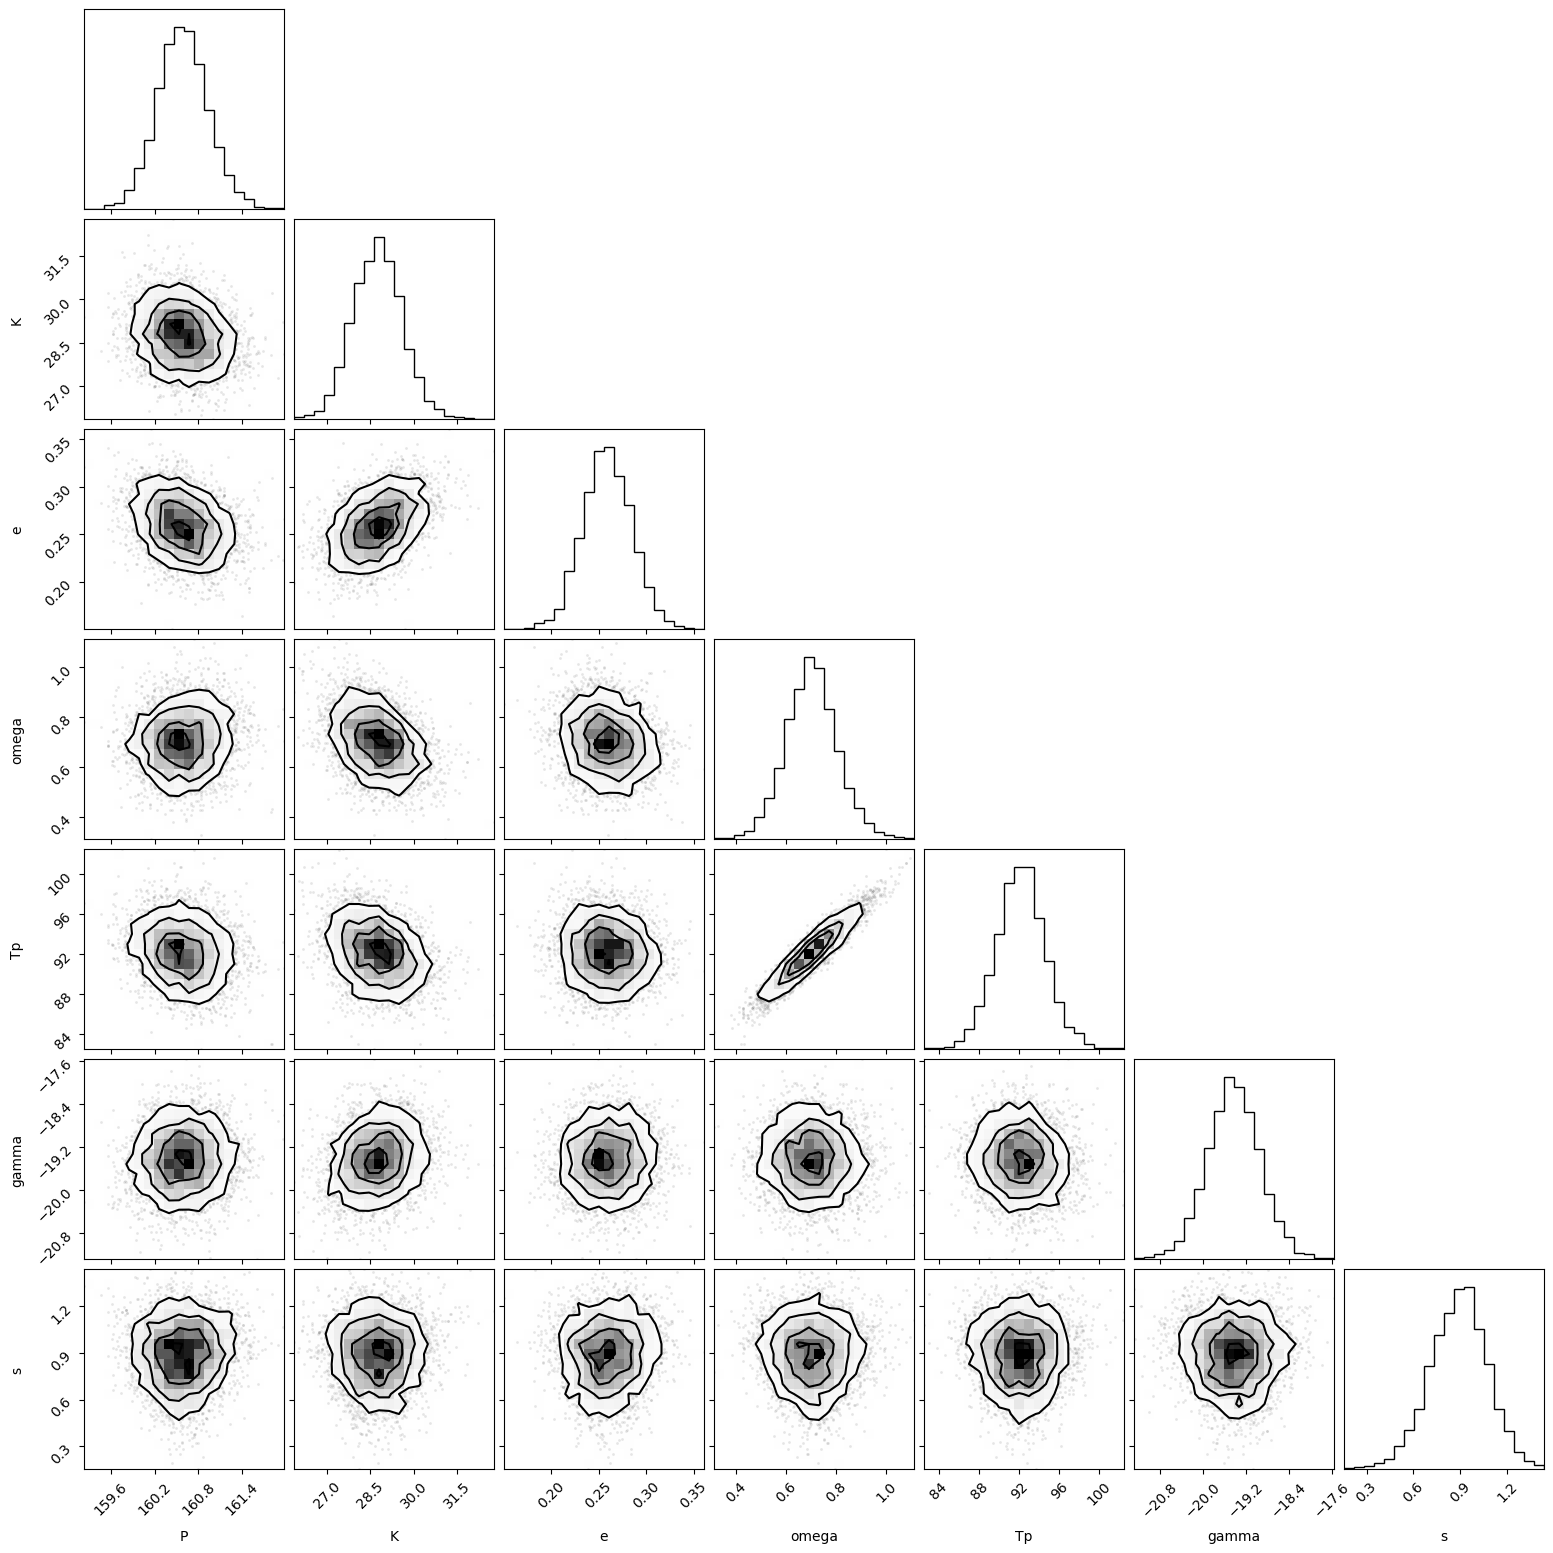

In [23]:
tau = sampler.get_autocorr_time()
flat_samples = sampler.get_chain(discard=100, thin=int((tau.max())/2), flat=True)
fig = corner.corner(
    flat_samples, labels=labels
);

In [24]:
labels = ["P", "K", "e", r"\omega", r"T_p", r"\gamma", "s"]

samples = flat_samples.copy()
samples[:, 6] = np.exp(samples[:, 6])
 
for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = r"\mathrm{{{3}}} = {0:.5f}_{{-{1:.5f}}}^{{+{2:.5f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**FINAL ANSWER:** 

$P = $ 160.4478 $\pm$ 0.4449 d, 
$K = $ 28.8550 $\pm$ 0.9510 km/s, 
$e = $ 0.2089 $\pm$ 0.0295, 
$\gamma = $ -20.5675 $\pm$  0.5606 km/s, 
jitter $s = $ 3.0374 $\pm$ 0.5085 km/s, 
$f(M) = $ 0.3727 $\pm$ 0.0351 $M_\odot$.

**Black-hole candidate?** Based on my calculated f(M) value of 0.3727 $M_\odot$, my star's companion is not a black-hole candidate.

## Part 3: The referee report (35%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident MCMC analysis of this exact
problem, produced by an AI assistant. It runs top to bottom without errors, the corner plot is handsome, and
the prose is fluent. It is also wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks and
style don't count; "it used 24 walkers and I used 32" is not a finding).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset: show, with a number or a plot, what the error
   does to the inference. For a sampler, "demonstrate" usually means running it the wrong way and the right
   way and comparing. A demonstration can come out negative: if an error turns out not to move *your*
   numbers, showing that, and saying what it would take for it to bite, is a valid finding.
3. **State** the correct treatment (you built it in Part 2).

Third time you have done this. You should be finding these in minutes now.


**REFEREE REPORT:**

Errors:
1. For the log prior, the AI bounds omega from $0$ to $2\pi$ and Tp from 0 to P. This is the exact trap mentioned in the first step of Part 2. There are two ways to avoid this, I opted to bound them within half a period of my starting value.
2. The AI computes the mass function from medians. The mass function should be computed for every posterior sample.
3. The radial velocity has jitter, which the AI does not account for within its log likelihood calculations anywhere. The variance is $\sigma_i^2 + s^2$ with s as the jitter term, not just $\sigma_i^2$.

In [25]:
# Part 3: your work here
def neglogL_AI(theta, t, rv, sig):
    P, K, e, omega, Tp, gamma = theta

    rv_pred = kepler_rv(t, P, K, e, omega, Tp, gamma)

    var = sig**2
    resid = rv - rv_pred

    return 0.5 * np.sum(resid**2 / var + np.log(2*np.pi*var))

def logL_AI(theta, t, rv, sig):
    P, K, e, omega, Tp, gamma = theta

    rv_pred = kepler_rv(t, P, K, e, omega, Tp, gamma)

    var = sig**2
    resid = rv - rv_pred

    return -0.5 * np.sum(resid**2 / var + np.log(2*np.pi*var))

theta_AI = [P3, 0.5 * (rv.max() - rv.min()), 0.3, 1.0, t.min() + 0.3 * P3, np.median(rv)]
m_AI = minimize(neglogL_AI, theta_AI, args = (t, rv, sig), method='Nelder-Mead')
P_AI, K_AI, e_AI, omega_AI, Tp_AI, gamma_AI = m_AI.x

def logprior_AI(theta_AI):
    P, K, e, omega, Tp, gamma = theta_AI

    if (1.0 < P < 300.0) & (1.0 < K < 50.0) & (0.1 <= e <= 0.6) & ((omega - P/2.0) < omega < (omega + P/2.0)) & ((Tp - P/2.0) < Tp < (Tp + P/2.0)) & (-50.0 < gamma < 50.0):
        return 0.0
        
    return -np.inf

def logprob_AI(theta_AI, t, rv, sig):
    lp = logprior_AI(theta_AI)
    
    if not np.isfinite(lp):
        return -np.inf

    return lp + logL_AI(theta_AI, t, rv, sig)

Text(0.5, 0, 'step number')

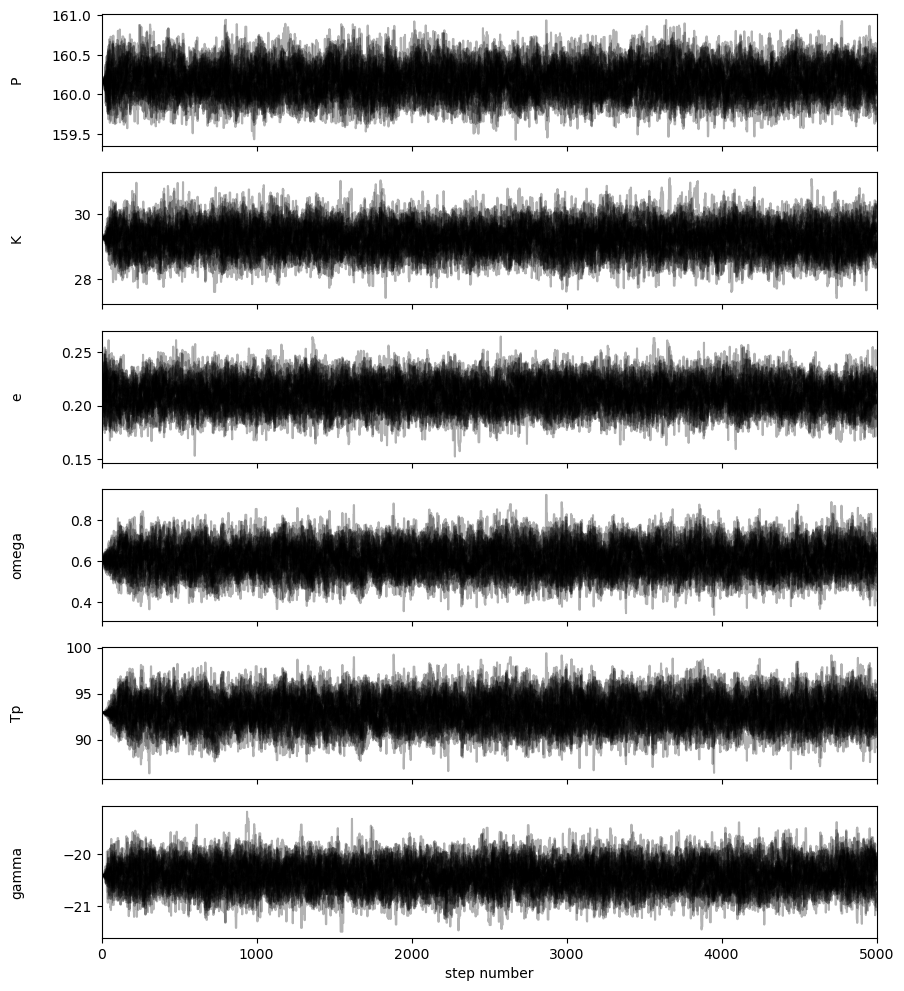

In [26]:
pos = m_AI.x + 1e-4 * np.random.randn(32, 6)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, logprob_AI, args=(t, rv, sig)
)
sampler.run_mcmc(pos, 5000)

fig, axes = plt.subplots(6, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()
labels = ['P', 'K', 'e', 'omega', 'Tp', 'gamma']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

[63.14040283 58.96893105 63.39004269 53.04738478 55.12185771 55.95393756]
(5056, 6)


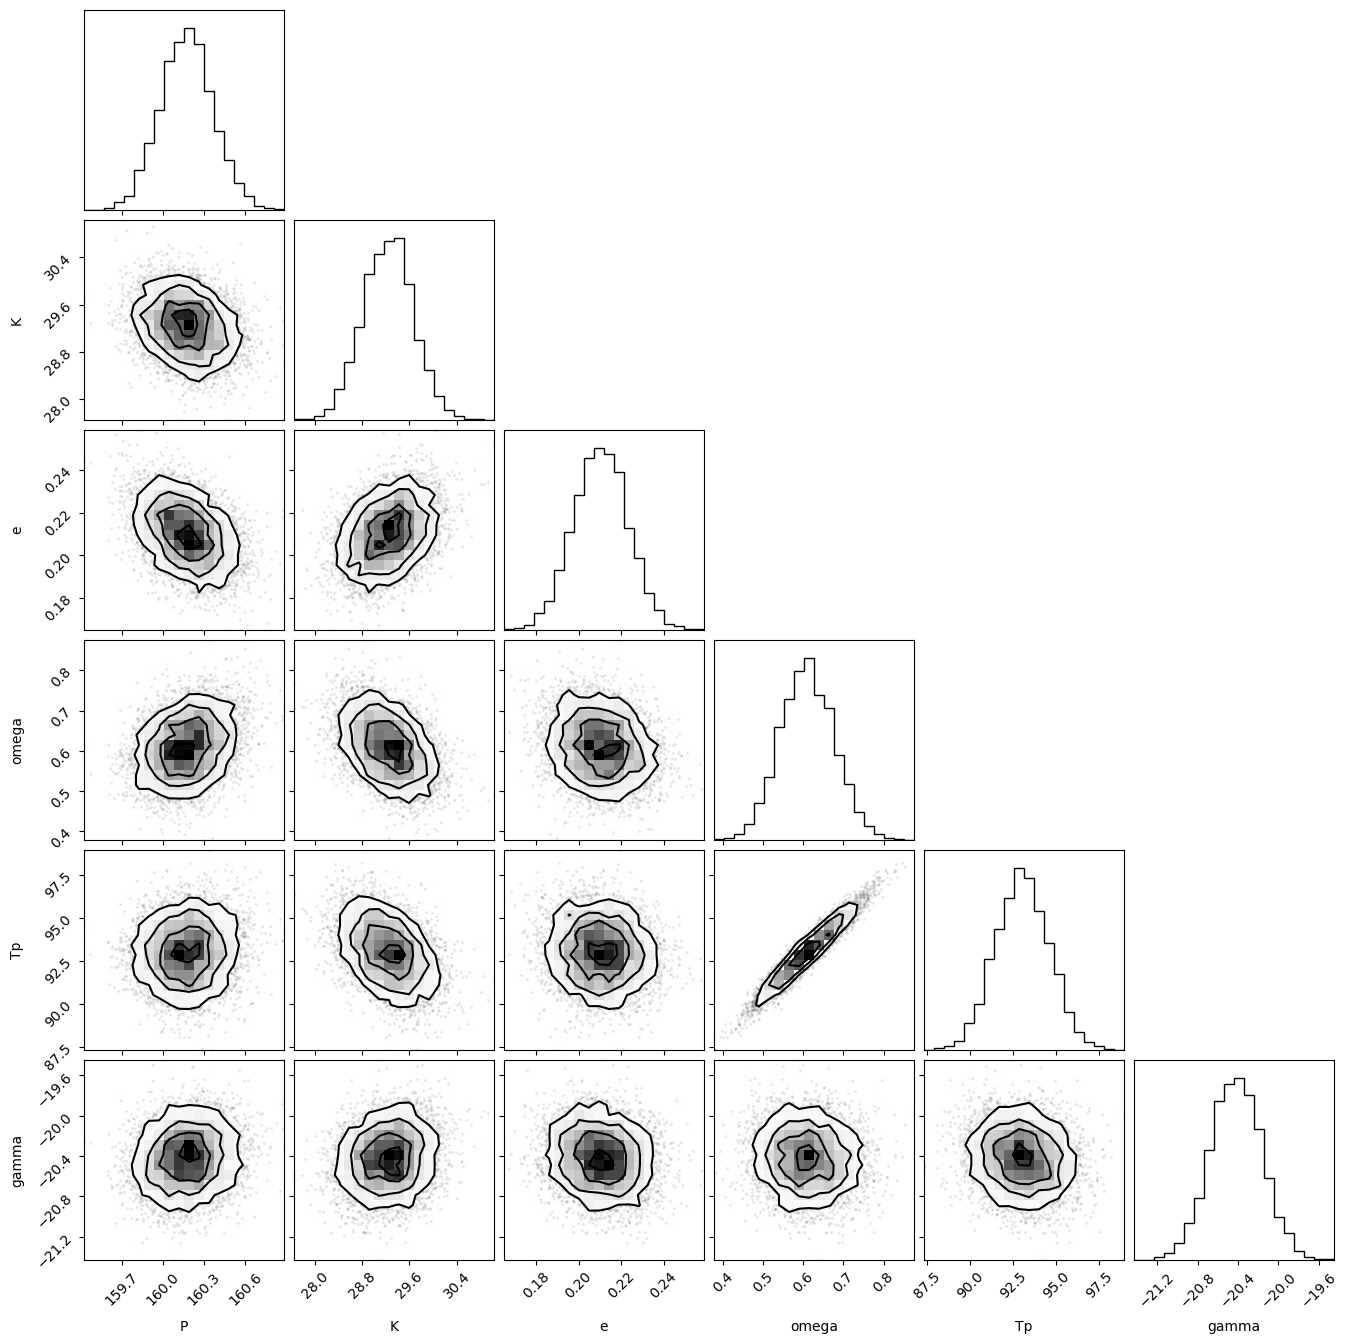

In [27]:
tau_AI = sampler.get_autocorr_time()
print(tau_AI)

flat_samples_AI = sampler.get_chain(discard=100, thin=int((tau_AI.max())/2), flat=True)
print(flat_samples_AI.shape)

#corner plots
fig = corner.corner(
    flat_samples_AI, labels=labels,
);

In [28]:
labels = ["P_AI", "K_AI", "e_AI", r"\omega_AI", r"T_pAI", r"\gamma_AI"]

for i in range(ndim):
    mcmc = np.percentile(flat_samples_AI[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = r"\mathrm{{{3}}} = {0:.5f}_{{-{1:.5f}}}^{{+{2:.5f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [29]:
med = np.median(flat_samples_AI, axis=0)
sd2 = np.std(flat_samples_AI, axis=0)

P_m, K_m, e_m = med[0], med[1], med[2]
fM_AI = mass_function(P_m, K_m, e_m)

fM_AI = 1.0361e-7 * (1 - e**2)**1.5 * K**3 * P
p16_AI, p50_AI, p84_AI = np.percentile(fM_AI, [16, 50, 84])

print(f"AI f(M): {p50_AI:.5f} -{p50_AI-p16_AI:.5f}/+{p84_AI-p50_AI:.5f} v. my f(M): {p50:.5f} -{p50-p16:.5f}/+{p84-p50:.5f}")

AI f(M): 0.37354 -0.00000/+0.00000 v. my f(M): 0.37278 -0.03354/+0.03682


## Part 4: AI-use appendix and verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did you catch it? Honesty
   is graded; "I didn't use any" is fine if true.
2. **Reflection (new from this lab on, two or three sentences)**: what did you use AI for in this lab, and
   what would have gone wrong in your answer if you had not checked its output? Name the specific thing, not
   "it could have made a mistake".
3. **Verification plan**: the checks you ran before trusting your Part 2 numbers, and what failure would have
   looked like for each. One you should seriously consider: generate a synthetic RV curve with parameters
   you choose, at *your* epochs, run your whole Part 2 pipeline on it, and see whether the 68% intervals
   contain what you put in. With seven parameters and one realisation, expect about five of seven inside
   their 68% intervals; one pull of 2.5σ is not a failure by itself. Failure looks systematic: the same
   parameter off in the same direction every time, or an interval that never contains the truth.


**AI-USE APPENDIX:**

I used Copilot for this assignment for help with coding in part 1, 2, and 4 (verification) of the lab. There were times when the AI incorrectly defined parameters due to lack of information from me. Such as it not knowing about the provided kepler_rv function. I checked all AI output against lecture and verified online information.

**REFLECTION:**

One thing that would have gone wrong in my answer if I had not checked the AI's output is the priors set for my logprior function. I asked AI for potential priors I could set, and the provided code had prior walls at $0$ and $2\pi$. Which is something the assignment specifically warns to avoid.

**VERIFICATION PLAN:**

For verification I ran the suggested check to generate a synthetic RV curve. If I repeatedly fail to recover the same values or outright recover none of them without reasonable cause, there may be an issue within my methods.